# Simple Grid World: Approximation

## Installation and Setup

You need:
* Gymnasium (see [Installation Instructions](../common/Setup_Gymnasium.ipynb))
* Patched `gym-classics-1.0.0+internal.rev1` or later (see [Installation instructions](../common/Setup_patched_gym_classics.ipynb))

In [1]:
import numpy as np
np.set_printoptions(precision=2)

In [2]:
import gymnasium as gym
import gym_classics
gym_classics.register('gymnasium')

## Define an Empty 5x5 Grid 

A maze without walls. The step cost is 1. The start is (0,0) and
the goal (+100 reward) is (4,4).
This is the ideal problem for a linear approximation of the Q-function
using the x/y location as state features.

In [3]:
from gym_classics.envs.abstract.gridworld import Gridworld

class EmptyGridworld(Gridworld):
    layout = """
|    G|
|     |
|     |
|     |
|S    |
"""

    def __init__(self):
        super().__init__(self.layout)

    def _reward(self, state, action, next_state):
        if state in self._goals:
            return 0.0
        return {(4, 4): 100.0}.get(next_state, -1)

    def _done(self, state, action, next_state):
        return next_state in self._goals   

gym.register('EmptyGridworld-v1', entry_point=EmptyGridworld)

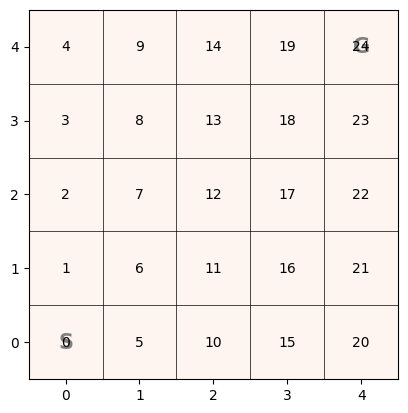

In [4]:
gym_env = gym.make('EmptyGridworld-v1')
#gym_env = gym.make('ClassicGridworld-v1')

env = gym_env.unwrapped

env.image()

## State Features

We use here simply the x and y-coordinates as the state feature vector $\mathbf{x}(s)$. We also add an intercept (a 1) to the beginning so we end up with a 3-dimensional state feature.

`[intercept (always 1), x, y]`


In [7]:
def state_features(s, env):
    coord = env.id2state(s)
    return np.concatenate([np.array([1]), np.array(coord)])

In [8]:
display(state_features(0, env))
display(state_features(1, env))

array([1, 0, 0])

array([1, 0, 1])

# Control: Semi-Gradient Sarsa

This is an on-policy control algorithm which has the following implications:

* It is required that the algorithm keeps exploring. We accomplish that by using an $\epsilon$-greedy. 
* This means we will not find the optimal deterministic policy, but the best $\epsilon$-greedy policy and its approximate value function.


![Semi-Gradient Sarsa](https://raw.githubusercontent.com/mhahsler/Introduction_to_Reinforcement_Learning/refs/heads/main/figures/RL-Intro_Alg_Semi_gradient_SARSA.png)

To construct a linear state-action approximation function is a little more tricky. [Geramifard et al. (2013)](https://doi.org/10.1561/2200000042) 
suggest to use a state feature vectors to construct the complete 
state-action feature vector. It uses one shared intercept and then for each action a state feature component.
In our case we get a $w$ vectors of length 1 intercept + 4 actions $\times$ 2 coordinate values = 9. Here is the layout for the weight vector $\mathbf{w}$:

`[intercept, x_action0, y_action0, x_action1, y_action1, x_action2, y_action2, x_action3, y_action3]`

Only the intercept and the weights belonging to the action are used for prediction nd in the update.

In [9]:
# choose intercept at 0 and the action-specific weights so we end up with 3 active weights.
def active_weights(a):
    return [0, a * 2 + 1, a * 2 + 2]

active_weights(1)

[0, 3, 4]

In [10]:
def q_hat(s, a, w, env): 
    return np.dot(w[active_weights(a)], state_features(s, env))

In [11]:
w = np.array([1,2,2,3,3,4,4,5,5])

# state 7 is (2,1): for action 2 this should be 1 (intercept) + 2*4+1*4 = 13
q_hat(7, 2, w,env)

np.int64(13)

In [12]:
from tqdm import tqdm

def semi_gradient_Sarsa_0(env, n, epsilon, alpha, gamma, w = None, max_episode_length=100, verbose = True):
    assert isinstance(env, gym.Env), "env must be an instance of gym.Env"
    assert alpha > 0 and alpha <= 1, "Alpha must be in (0,1]"
    assert gamma >= 0 and gamma <= 1, "Gamma must be in [0,1]"
    assert epsilon >=0 and epsilon <=1, "Epsilon must be in [0,1]"
    assert n > 0, "Number of episodes must be positive"
    assert max_episode_length > 0, "Max episode length must be positive"

    if w is None:
        w = np.zeros(9)  # Initialize weights (intercept + action weights)

    # helper used later
    def epsilon_greedy_action(state, epsilon):
        if np.random.rand() < epsilon:
            return env.action_space.sample()
        else:
            q_values = [q_hat(state, a, w,env) for a in range(env.action_space.n)]
            return np.argmax(q_values)
    
    for episode in tqdm(range(n), desc="Episodes", disable=verbose):
        state, _ = env.reset()
        action = epsilon_greedy_action(state, epsilon)
        done = False

        i = 0
        while not done and i < max_episode_length:
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            
            if terminated:
                next_action = None
                w[active_weights(action)] += alpha * (reward - q_hat(state, action, w,env)) * state_features(state, env)
                
            else:
                next_action = epsilon_greedy_action(next_state, epsilon)
                w[active_weights(action)] += alpha * (reward + gamma * q_hat(next_state, next_action, w,env) - q_hat(state, action, w,env)) * state_features(state, env)
             
            if verbose:
                print (f"Episode {episode+1}, Step {i+1}: S={state}, A={action}, R={reward}, S'={next_state}, w={w}")

            state = next_state
            action = next_action
            i += 1

    return w  
    

### Tests With Different Learning Rates 

In [17]:
# helper to visualize the learned policy and value function 
def plot_w(w, title=None):
    Q = np.array([[q_hat(s, a, w, env) for a in range(env.action_space.n)] for s in range(env.observation_space.n)])
    
    # discourage leaving the grid for tie breaking. This is important because the empty maze has a perfectly symmetric value function.
    ids = env.to_matrix()
    Q[ids[:,-1],env.action2id("right")] -= .1
    Q[ids[:,0],env.action2id("left")] -= .1
    Q[ids[0,:],env.action2id("down")] -= .1
    Q[ids[-1,:],env.action2id("up")] -= .1
    
    V = np.max(Q, axis=1)
    pol = np.argmax(Q, axis=1)
    env.image(V, policy=pol, title=title)
    
    return Q, V, pol

In [18]:
env.to_matrix()


array([[ 0,  5, 10, 15, 20],
       [ 1,  6, 11, 16, 21],
       [ 2,  7, 12, 17, 22],
       [ 3,  8, 13, 18, 23],
       [ 4,  9, 14, 19, 24]])

Convergence is an issue with semi-gradient methods and heavily depends on the choice of the learning rate.

Episodes: 100%|██████████| 1000/1000 [00:12<00:00, 79.48it/s]


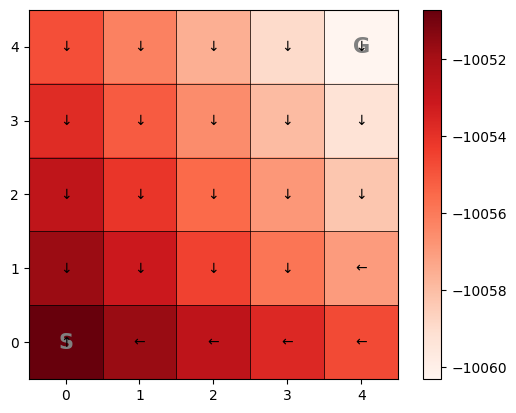

(array([[-10050.72, -10050.72, -10050.82, -10050.82],
        [-10053.55, -10054.16, -10051.75, -10053.09],
        [-10056.38, -10057.6 , -10052.77, -10055.35],
        [-10059.21, -10061.03, -10053.8 , -10057.61],
        [-10062.14, -10064.47, -10054.83, -10059.87],
        [-10053.94, -10053.83, -10052.19, -10051.72],
        [-10056.77, -10057.27, -10053.12, -10053.98],
        [-10059.6 , -10060.7 , -10054.14, -10056.25],
        [-10062.43, -10064.14, -10055.17, -10058.51],
        [-10065.36, -10067.58, -10056.2 , -10060.77],
        [-10057.16, -10056.94, -10053.56, -10052.72],
        [-10059.99, -10060.37, -10054.49, -10054.98],
        [-10062.82, -10063.81, -10055.51, -10057.24],
        [-10065.65, -10067.25, -10056.54, -10059.51],
        [-10068.58, -10070.68, -10057.57, -10061.77],
        [-10060.37, -10060.04, -10054.93, -10053.72],
        [-10063.2 , -10063.48, -10055.86, -10055.98],
        [-10066.03, -10066.92, -10056.89, -10058.24],
        [-10068.86, -10070.3

In [19]:
w = semi_gradient_Sarsa_0(env, n=1000, epsilon=0.1, alpha=0.1, gamma=1, verbose=False)
plot_w(w)

Learning most likely did not converge! We need to reduce the learning rate.

Episodes: 100%|██████████| 100/100 [00:00<00:00, 1125.25it/s]


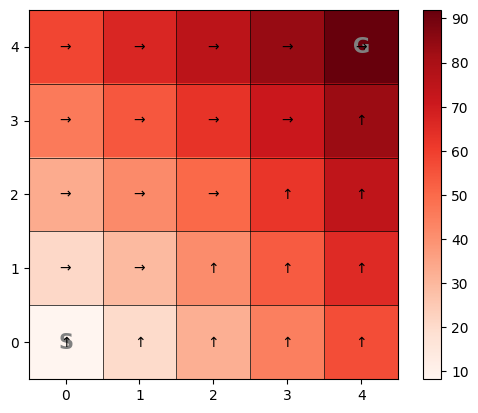

In [20]:
w = semi_gradient_Sarsa_0(env, n=100, epsilon=0.1, alpha=0.001, gamma=1, verbose=False)
Q, V, pol = plot_w(w)

Even a very small number of sampled episodes is enough to learn a value function that leads to a good policy.

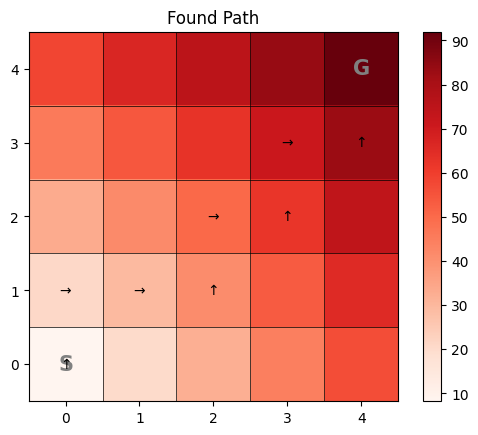

In [21]:
from gym_classics.algorithms.monte_carlo_methods import sample_episode

path = sample_episode(env, policy=pol, max_len=100)
env.image(V, policy=pol, episode=path, title='Found Path')

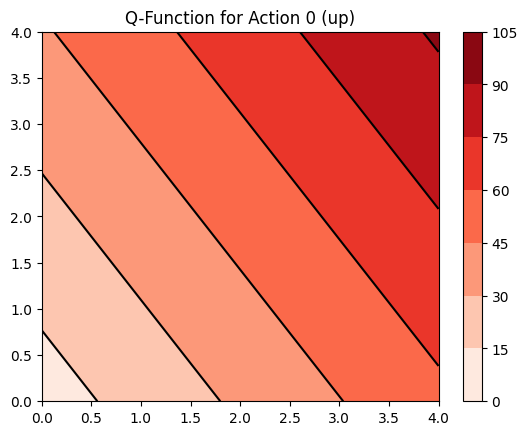

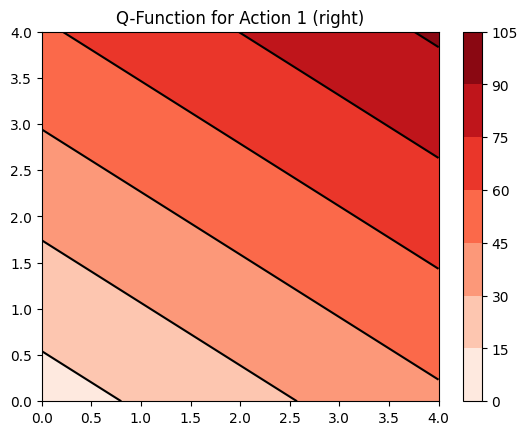

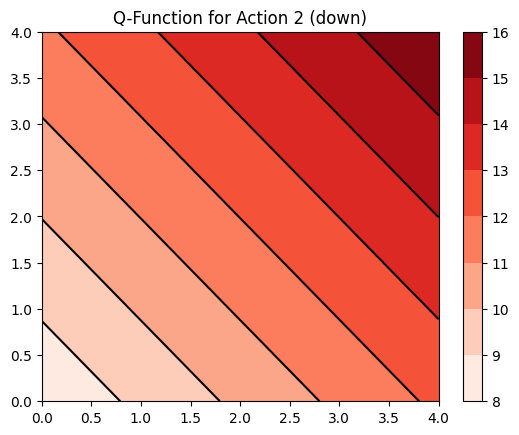

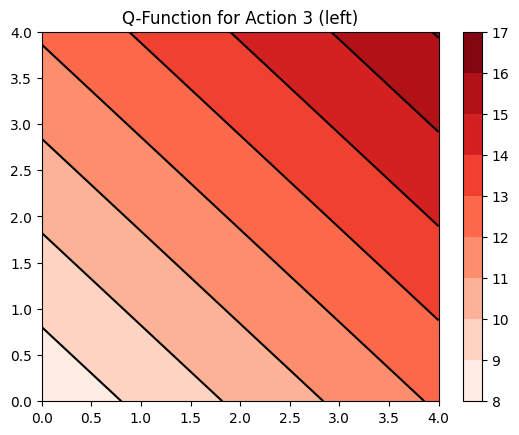

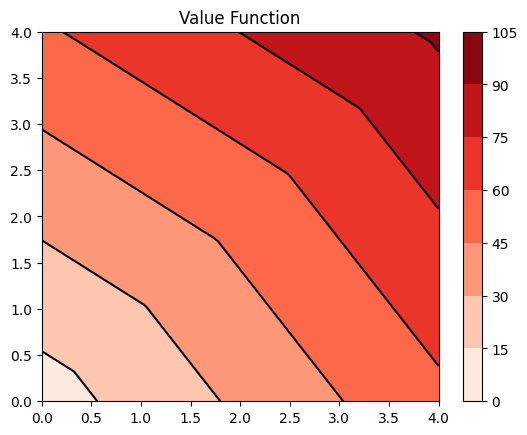

In [25]:
from matplotlib import pyplot as plt

def q_hat_grid(x, y, a, w):
    return np.dot(w[active_weights(a)], [1, x, y])

x = np.linspace(0, 4, 100)
y = np.linspace(0, 4, 100)
X, Y = np.meshgrid(x, y)

# plot the Q-function for each action
for a in range(len(env.actions())):
    Z = np.array([q_hat_grid(x, y, a, w) for x, y in zip(np.ravel(X), np.ravel(Y))]).reshape(X.shape)

    plt.contourf(X, Y, Z, cmap='Reds')
    plt.colorbar()
    plt.title(f'Q-Function for Action {a} ({env.id2action(a)})')
    plt.contour(X, Y, Z, colors='black') # Contour lines
    plt.show()
    
# plot the value function
Z = np.array([np.max([q_hat_grid(x, y, a, w) for a in range(env.action_space.n)]) for x, y in zip(np.ravel(X), np.ravel(Y))]).reshape(X.shape)
plt.contourf(X, Y, Z, cmap='Reds')
plt.colorbar()
plt.title('Value Function')
plt.contour(X, Y, Z, colors='black') # Contour lines
plt.show()

Let's compare the learned value function with it with the optimal value function. Since we have model access, we can calculate it using value iteration.

In [26]:
from gym_classics.algorithms.dynamic_programming import value_iteration
V_true = value_iteration(env, discount = 1)
V_true 

Value Iteration: 9it [00:00, 1192.96it/s]


array([ 93.,  94.,  95.,  96.,  97.,  94.,  95.,  96.,  97.,  98.,  95.,
        96.,  97.,  98.,  99.,  96.,  97.,  98.,  99., 100.,  97.,  98.,
        99., 100., 100.])

Here is the learned value function implied in the approximate Q-value function.

In [27]:
V

array([ 8.21, 20.71, 33.22, 45.72, 58.22, 20.32, 29.18, 41.68, 54.19,
       66.69, 32.42, 41.25, 50.15, 62.65, 75.16, 44.52, 53.35, 62.18,
       71.12, 83.62, 56.63, 65.45, 74.28, 83.11, 91.99])

The mean square value error measures the error of a value function given the true value function. It is typically weighted by how likely it is for the agent to be in a state (i.e., the stationary on-policy state distribution $\mu(s)$).

In [28]:
# mean squared value error. For the measure, the error for each state is typically weighted by how often it occurs.
# If no weight vector is given then we calculate the unweighted error.
def MSVE(V, V_true, weight=None):
    if weight is None:
        weight = np.ones(len(V))
    
    return np.sum(weight * (V - V_true)**2)

Let's estimate $\mu(s)$ via sampling. Note: If we have model access then we could also directly calculate the distribution (see textbook).

In [29]:
def on_policy_state_distribution(env, pol, epsilon = 0, n = 1):
    episodes = np.concat([sample_episode(env, policy=pol, epsilon = epsilon) for _ in range(n)])
    states = episodes[:,0]
    state_cnts = np.array([list(states).count(s) for s in range(env.observation_space.n)])
    state_prob = state_cnts / sum(state_cnts)
    return state_prob

In [30]:
state_prob = on_policy_state_distribution(env, pol, epsilon = .1, n = 100)
state_prob

array([0.12, 0.12, 0.01, 0.  , 0.  , 0.  , 0.11, 0.01, 0.  , 0.  , 0.  ,
       0.11, 0.12, 0.01, 0.  , 0.  , 0.01, 0.12, 0.12, 0.  , 0.  , 0.  ,
       0.01, 0.12, 0.  ])

In [31]:
msve = MSVE(V, V_true, weight=state_prob)
msve_sqrt = np.sqrt(msve)

print(f"MSVE: {msve}, sqrt(MSVE): {msve_sqrt}")

MSVE: 3042.161057519423, sqrt(MSVE): 55.15578897558645


The error is extremely high. The reason is that we learned with a very small number of episodes and a low learning rate. 

### Experiment With Learning

The gym-classics implementation can return the weights after each episode.

**Note:** I use discounting so we can see how fast the goal is found!

In [41]:
from gym_classics.algorithms.linear_approximation import semi_gradient_Sarsa_0
gym_classics.algorithms.linear_approximation.state_features = state_features

w, history = semi_gradient_Sarsa_0(env, n=1000, epsilon=0.1, alpha=0.0001, gamma=.9, history=True)

Semi-Gradient SARSA(0): 100%|██████████| 1000/1000 [00:01<00:00, 595.87it/s]


Return over episodes.

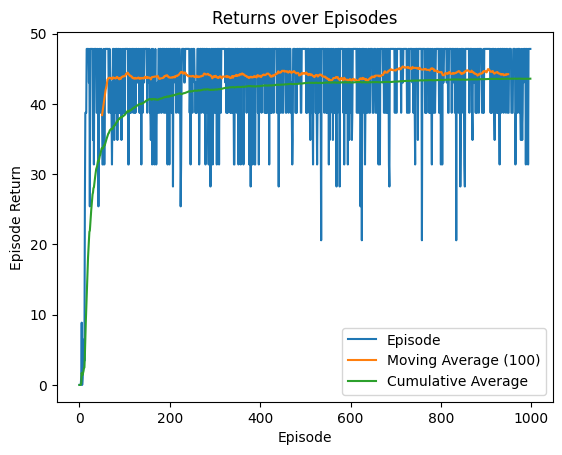

In [42]:
from gym_classics.performance import plot_returns

plot_returns(history["returns"][1:], title="Returns over Episodes")

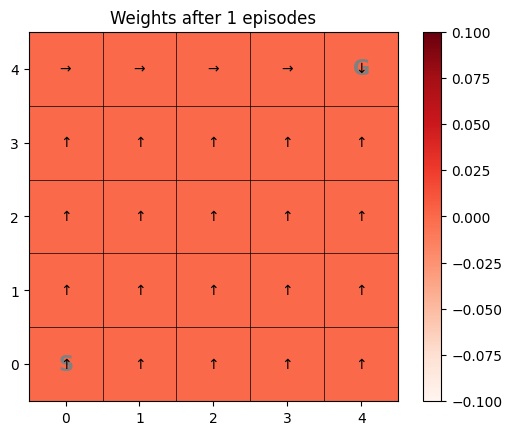

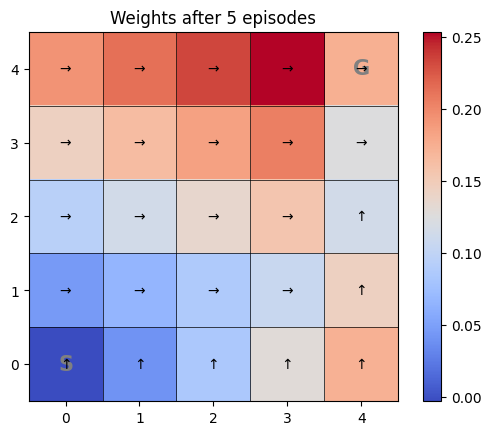

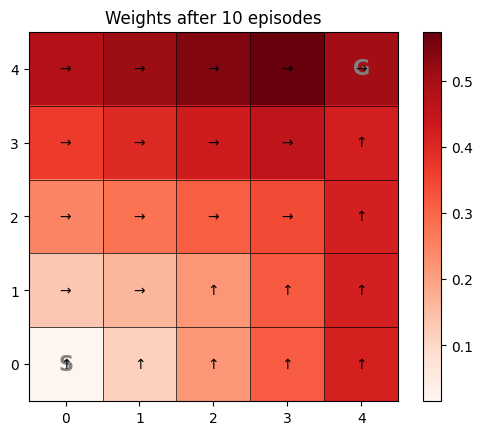

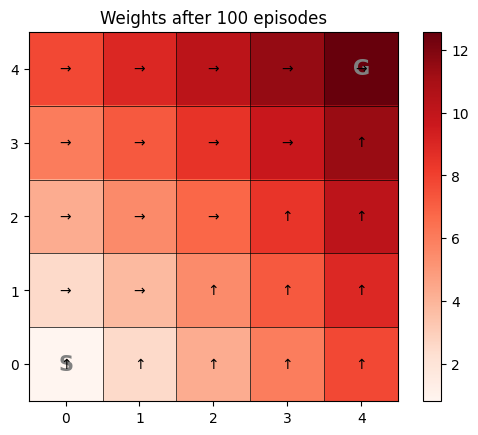

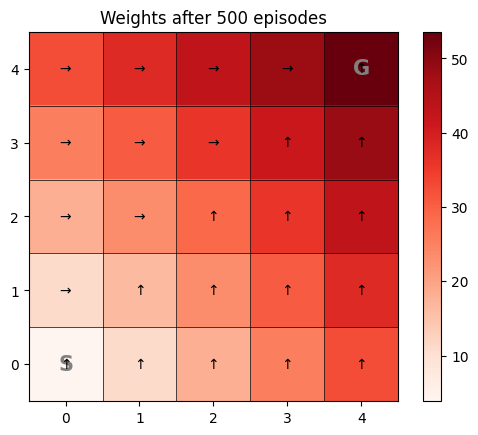

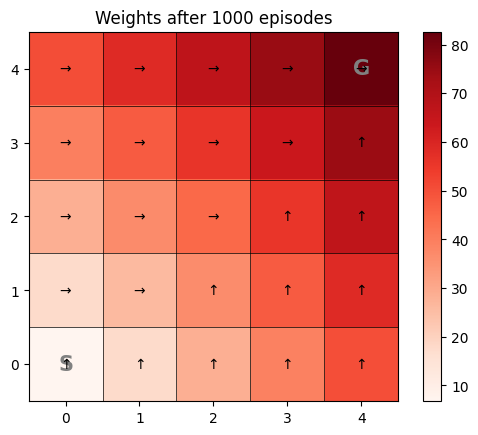

In [48]:
for i in [0,4, 9, 99, 499, 999]:
    Q, V, pol = plot_w(history["ws"][i], title=f"Weights after {i+1} episodes")    

Look at MSVE over episodes.

In [55]:
def MSVE_w(w, weight=None):
    Q = np.array([[q_hat(s, a, w, env) for a in env.actions()] for s in env.states()])
    V = np.max(Q, axis=1)
    return MSVE(V, V_true, weight=weight)  

all_but_final_state = [1]*(len(env.states())-1)+[0]

msve = [MSVE_w(w, weight=all_but_final_state) for w in history["ws"]]

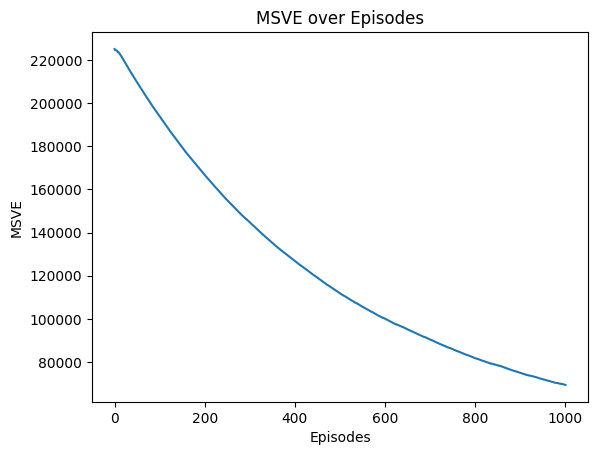

In [56]:
import matplotlib.pyplot as plt 

# plot MSVE over episodes
plt.plot(msve)
plt.xlabel('Episodes')
plt.ylabel('MSVE')
plt.title('MSVE over Episodes')
plt.show()


Notes:

* Too large learning rate will destabilize the estimation over time! A schedule to reduce $\alpha$ over time can be used.
* $\epsilon$ can be reduced with a schedule over time to converge to the optimal policy (GLIE).


&copy; 2025 [Michael Hahsler](http://michael.hahsler.net). 
This work is openly licensed under [Creative Commons Attribution-ShareAlike 4.0 International (CC BY-SA 4.0) License](https://creativecommons.org/licenses/by-sa/4.0/)

![CC BY-SA 4.0](https://licensebuttons.net/l/by-sa/3.0/88x31.png)